### Question 1
Mr Saver invested 50,000 in a Certificate of Deposit account with a bank. The interest  rate is ln 1.01 compounded continuously with the maturity being 5 years. If unfortunately, Mr Saver had to withdraw all money at the end of the 4th year. As an early withdraw penalty, Mr Saver had to pay $ \frac{1}{3} $ of the interest of the 4th year. Calculate Mr Saver’s total earnings to 4 decimal places.


#### Core Principle
$$ v(t) = a(t) * Principle $$
$$ a(t) = exp(r \times t) ~~| ~~ r = ln(1.01)$$

#### Solution
Interest + Principle for first 3 years = $ 50000 \times e^{ ln(1.01) \times 3} = 50000 \times 1.01^3 = 51515.0500$

Interest for Year 4 = $ 51515.0500 \times e^{ln 1.01} - 51515.0500 = 515.1505 $

Penalty = $515.1505 \div 3 = 171.7168$

Total Interest Revenue = $51515.0500 \times e^{ln 1.01} - 171.7168 - 50000 = 1858.4837$

#####

In [9]:
import numpy as np
a = np.exp(np.log(1.01)*3)*50000
b = a * np.exp(np.log(1.01)) - a
round(a * np.exp(np.log(1.01)) - b/3 -50000,4)

np.float64(1858.4837)

### Question 2
Wonderful Land is planning to issue a Treasury bill. Given the following details, you are 
required to calculate the issue price of commercial paper. 

| Face Value | Maturity Period | Market Rate |
|:---------------:|:--------------:|:---------------:|
| 2,500,000 | 3m |10.5% |

#### Core Principle
Where t is in months
$$ a(t) = \left(1+\frac{r\times t}{n}\right) ~~| ~~t = 3$$

#### Solution
$ a(3) = \left(1+\frac{0.105 \times 3}{12}\right) = 1.02625 $

$P = 2,500,000 \div a(3) = 2,436,054 $

##### 

In [17]:
at = 1+0.105*3/12
p = 2500000/at
round(p,0)

2436054.0

### Question 3

ABC Inc. issued a 180-day, 1,000,000 commercial paper on Jan 1 2026, when the market 
rate of return was 3.65%. Investor 1 purchased the commercial paper on its issue date at 
price $P_0$, and sold it to Investor 2 at price $P_1$ after 30 days when the market rate of return 
was 3.68%. Take 1 year as 365 days, calculate $P_0$, $P_1$, and Investor 1’s nominal rate of 
return to 4 decimal places. 

#### Core Principle

$$ P =\frac{F}{1+r_t \times t/365} $$

$$ r = \left( \frac{P_{1}}{P_{0}} - 1 \right) \times \frac{365}{\Delta t} $$

Where $\Delta t = t_2 - t_1$ where t is in days

#### Solution

$ P_0 =  \frac{1000000 }{1+ 0.0365 \times 180/365} = 982,318.27 $

$ P_1 =   \frac{1000000}{1+ 0.0368 \times 150/365} = 985,102.02 $

$ r = \left( \frac{985,102.02}{982,318.27} - 1 \right) \times \frac{365}{30} = 3.4478\% $


######

In [19]:
p0 = 1000000 / (1+0.0365 *180/365)
p1 = 1000000 / (1+0.0368 *150/365)
r = (p1/p0 -1) *365 / 30

print(p0,p1,r)

982318.2711198428 985102.0187844111 0.03447857065745622


### Question 4

A 10-year bond with face value $100 pays coupons semi-annually at a nominal annual rate 
of 6%, and it is redeemable at face value. Find the bond price if the effective annual bond 
yield is 8%. 

#### Core Principle

| Notation | Definition |
|:---------------:|:--------------:|
| $P$ | Current price |
| $F$ | Face Value |
| $R$ | Redemption value |
| $c$ | Nominal coupon rate |
| $m$ | No. of payments a year |
| $n$| Total no. of payments = t*m |
| $\lambda$ | Nominal yield |
| $r_e$ | Effective rate |

Nominal yield

$$ \lambda = \left((1+r_e)^{1/m} -1\right) \times m $$

Cash flow formula

$$ P = \frac{R}{(1+\lambda/m)^{n}} +\sum_{i = 1}^{n} \frac{cF/m}{(1+\lambda/m)^{i}} $$

Prof's formula

$$ P = F+F\left(\frac{c-\lambda}{\lambda}\right) \left[ 1- \frac{1}{\left( 1+ \frac{\lambda}{m} \right)^n}\right] $$

My closed form

$$ P = \frac{R}{(1+\lambda/m)^{n}} + cF/m \times \frac{1-(1+\lambda/m)^{-n}}{\lambda/m}$$

#### Solution
Nominal yield

$ \lambda = \left((1+0.08)^{1/2} -1\right) \times 2 = 7.846096908\% $

Method 1

$ P = 100+100\left(\frac{0.06-\lambda}{\lambda}\right) \left[ 1- \frac{1}{\left( 1+ \frac{\lambda}{2} \right)^{20}}\right] = 87.3695564 \approx 87.37 $

Method 2

$ P = \frac{100}{(1+\lambda/2)^{20}} + 0.06 \times 100/2 \times \frac{1-(1+\lambda/2)^{-20}}{\lambda/2} = 87.3695564 \approx 87.37 $


#####

In [34]:
y = ((1+0.08)**0.5 -1)*2
bond1 = 100+100*(0.06-y)/y*(1- (1+y/2)**-20) 
bond2 = 100/(1+y/2)**20 + 3 * (1-(1+y/2)**-20)/(y/2)
print(round(y*100,4),round(bond1,4),round(bond2,4),bond1 == bond2)

7.8461 87.3696 87.3696 True


### Question 5
A 20-year bond of face value 100 is redeemable at par. The bond pays coupons quarterly. 
The nominal coupon rate for this bond is 4% for the 1st 5 years, 6% for the 2nd 5 years, 8% 
for the 3rd 5 years, and 10% for the last 5 years. If the nominal bond yield is 8% convertible 
quarterly, find the expected price of the bond to 4 decimal places. 

#### Core Principle

Cash flow diagram 

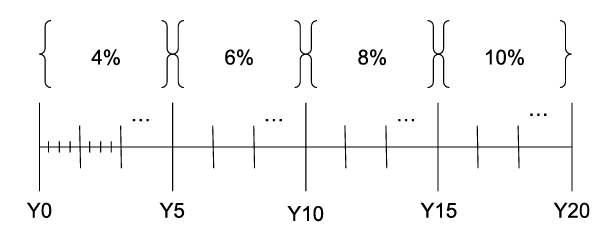

Present value formula (where $PV_t$ denotes the present value at quarter $t$)

$$ PV_t(CF_i) =   \frac{CF_i}{(1+\lambda/m)^{i-t}} $$ 

Where i denotes the i th cashflow relative to quarter 0

Similar to Question 4

Prof's formula

$$ P = F+F\left(\frac{c-\lambda}{\lambda}\right) \left[ 1- \frac{1}{\left( 1+ \frac{\lambda}{m} \right)^n}\right] $$

Closed form formula

$$ P = \frac{R}{(1+\lambda/m)^{n}} + cF/m \times \frac{1-(1+\lambda/m)^{-n}}{\lambda/m}$$

**Method: Seperate each 5 year block into a single Cash flow, you will get 4 blocks of 5 years.**

#### Solution

Notations: $i \to 1$ quarter $PV_t() \to$ Present value at $t$ th quarter $CF_i \to $ cashflow at $i$th quarter

At **year 0**: Present value of cash flows for **year 1 to 5**

$\begin{align} \sum_{i = 1}^{20} PV_0(CF_i) &= \sum_{i = 1}^{20} \frac{0.04\times 100\div 4}{(1+0.08/4)^{i}} \notag \\ &= 0.04\times 100\div 4 \times \frac{1-(1+0.08/4)^{-20}}{0.08/4} \notag \\ &\approx 16.3514 \end{align}$

$~$

At **year 5**: Present value of cash flows for **year 6 to 10**

$\begin{align}\sum_{i = 21}^{40} PV_{20}(CF_i) &= \sum_{i = 1}^{20} \frac{0.06\times 100\div 4}{(1+0.08/4)^{i}} \notag \\ &= 0.06\times 100\div 4 \times \frac{1-(1+0.08/4)^{-20}}{0.08/4} \notag \\ &\approx 24.5272 \end{align}$

$~$

At **year 10**: Present value of cash flows for **year 11 to 15**

$ \begin{align} \sum_{i = 41}^{60} PV_{40}(CF_i) &= \sum_{i = 1}^{20} \frac{0.08\times 100\div 4}{(1+0.08/4)^{i}}\notag \\ &= 0.08\times 100\div 4 \times \frac{1-(1+0.08/4)^{-20}}{0.08/4} \notag \\ &\approx 32.7029 \end{align}$

$~$

At **year 15**: Present value of cash flows for **year 16 to 20**

$\begin{align}
\sum_{i = 61}^{80} PV_{60}(CF_i) &= \sum_{i = 1}^{20} \frac{0.10\times 100\div 4}{(1+0.08/4)^{i}} + 100 \times (1+0.08/4)^{-20} \notag \\ &= 0.10\times 100\div 4 \times \frac{1-(1+0.08/4)^{-20}}{0.08/4} + 100 \times (1+0.08/4)^{-20} \notag \\ &\approx 108.1757 \end{align}$

$~$

**Price of bond**: Present value of cash flows from **year 1 to 20** at **year 0**

$\begin{align}
P &= \sum_{i = 1}^{80} PV_0(CF_i) \notag \\
  &= \sum_{i = 1}^{20} PV_0(CF_i) 
   + PV_0\left(\sum_{i = 21}^{40} PV_{20}(CF_i)\right)
   + PV_0\left(\sum_{i = 41}^{60} PV_{40}(CF_i)\right)
   + PV_0\left(\sum_{i = 61}^{80} PV_{60}(CF_i)\right) \notag \\
  &= \sum_{i = 1}^{20} PV_0(CF_i) 
   + \frac{\sum_{i = 21}^{40} PV_{20}(CF_i)}{(1+0.08/4)^{20}}
   + \frac{\sum_{i = 41}^{60} PV_{40}(CF_i)}{(1+0.08/4)^{40}}
   + \frac{\sum_{i = 61}^{80} PV_{60}(CF_i)}{(1+0.08/4)^{60}} \notag \\
  &\approx 80.6384
\end{align}$


######

In [47]:
y = 0.08
cf1 = 1 * (1-(1+y/4)**-20)/(y/4)
cf2 = 1.5 * (1-(1+y/4)**-20)/(y/4)
cf3 = 2 * (1-(1+y/4)**-20)/(y/4)
cf4 = 2.5 * (1-(1+y/4)**-20)/(y/4) + 100 * (1+0.08/4)**-20
round(cf1+ (1+0.08/4)**-20*cf2+ (1+0.08/4)**-40*cf3 +(1+0.08/4)**-60*cf4,4)

80.6384